# 04 — Network Analysis
**Goal:** Analisis jaringan buyer-seller untuk identifikasi cluster fraud, node sentral, dan pola mencurigakan.
**Input:** `fraud_predictions.csv`

## 0. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

sns.set_theme(style='whitegrid')
%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'
REPORTS_DIR   = Path('..') / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'fraud_predictions.csv')
df['transaction_created_datetime'] = pd.to_datetime(df['transaction_created_datetime'])

print(f'Shape          : {df.shape}')
print(f'Fraud rate     : {df["is_fraud"].mean()*100:.2f}%')
print(f'Unique buyers  : {df["buyer_id"].nunique():,}')
print(f'Unique sellers : {df["seller_id"].nunique():,}')

Shape          : (26772, 27)
Fraud rate     : 17.31%
Unique buyers  : 6,498
Unique sellers : 413


## 1. Bangun Graph Buyer-Seller

In [3]:
# Agregasi edge weight = total transaksi per pasangan
edge_df = (
    df.groupby(['buyer_id', 'seller_id'])
    .agg(
        weight        = ('transaction_amount', 'sum'),
        tx_count      = ('dpt_id', 'count'),
        fraud_count   = ('is_fraud', 'sum'),
        fraud_prob_avg= ('fraud_probability', 'mean'),
    )
    .reset_index()
)
edge_df['fraud_rate'] = edge_df['fraud_count'] / edge_df['tx_count']

print(f'Total edges (pasangan unik): {len(edge_df):,}')
print(f'Edges dengan fraud >= 1    : {(edge_df["fraud_count"] > 0).sum():,}')
edge_df.head()

Total edges (pasangan unik): 6,794
Edges dengan fraud >= 1    : 559


,buyer_id,seller_id,weight,tx_count,fraud_count,fraud_prob_avg,fraud_rate
0,001046b5061e28476b83fe2335b04d3210bed72a2fee17...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,5.000008e+08,2,0,0.560838,0.0
1,00119737eef11ff1d30c2061dd1e19c06d963d5a125c92...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,2.029000e+07,1,0,0.203081,0.0
2,0012614e5a1366f102a3497b67f8ec9a8009c802aa6959...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,1.250000e+04,1,0,0.013552,0.0
3,0013cdaff46e67574660e0ddd214e5032e3ff5d94744e1...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,3.711315e+07,13,0,0.153694,0.0
4,001aa5e447130ae69fb4699960094fe6d8f7aa1178f23d...,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,9.000000e+07,1,0,0.192016,0.0


In [4]:
# Bangun directed graph
G = nx.DiGraph()

for _, row in edge_df.iterrows():
    G.add_edge(
        row['buyer_id'], row['seller_id'],
        weight         = float(row['weight']),
        tx_count       = int(row['tx_count']),
        fraud_count    = int(row['fraud_count']),
        fraud_rate     = float(row['fraud_rate']),
        fraud_prob_avg = float(row['fraud_prob_avg']),
    )

print(f'Nodes : {G.number_of_nodes():,}')
print(f'Edges : {G.number_of_edges():,}')
print(f'Density: {nx.density(G):.6f}')

Nodes : 6,843
Edges : 6,794
Density: 0.000145


## 2. Node Centrality — Siapa yang Paling Sentral?

In [5]:
# Hitung berbagai centrality metrics
print('Menghitung centrality metrics...')

in_degree   = dict(G.in_degree(weight='tx_count'))
out_degree  = dict(G.out_degree(weight='tx_count'))
pagerank    = nx.pagerank(G, weight='tx_count', max_iter=200)

# Untuk betweenness — sample karena graph besar
G_undirected = G.to_undirected()
betweenness  = nx.betweenness_centrality(G_undirected, k=min(500, G.number_of_nodes()), normalized=True)

centrality_df = pd.DataFrame({
    'node'        : list(pagerank.keys()),
    'pagerank'    : list(pagerank.values()),
    'in_degree'   : [in_degree.get(n, 0)  for n in pagerank],
    'out_degree'  : [out_degree.get(n, 0) for n in pagerank],
    'betweenness' : [betweenness.get(n, 0) for n in pagerank],
}).sort_values('pagerank', ascending=False)

print('\nTop 10 node by PageRank (buyer/seller paling berpengaruh):')
centrality_df.head(10)

Menghitung centrality metrics...

Top 10 node by PageRank (buyer/seller paling berpengaruh):


,node,pagerank,in_degree,out_degree,betweenness
1,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,0.430581,26009,0,9.265430e-01
442,93628e8e3030e3e1d4f0c4288991fac02621374a426317...,0.000635,4,3,3.971154e-06
2929,cc5931492ffb69621da4f4b6d075380baf7d46e7e7af28...,0.000490,6,1,7.308873e-08
441,388dbd8594db84a0485ad0085b7b2cceef013e10ca3e72...,0.000451,4,0,2.685291e-07
124,985cafd6d0d1c62748bbcfe8be780c09de7ce6b80a6d67...,0.000433,2,8,4.970034e-06
2928,6e0fe0280311be18ab37e2ac10675354464e6448e38e4e...,0.000398,2,3,3.410807e-07
6241,ead119c5d1130dc62b309d38a8fa74bc85c9e4302edb6f...,0.000391,6,7,1.406227e-04
6242,f8f0c08ca6837bf7f41fb600ea803a0131db88f1794b85...,0.000366,6,6,0.000000e+00
4136,266acfce09ab5e97c4ae64e08509929715f87c86e11377...,0.000246,2,0,0.000000e+00
6237,43e25697791837e225e70ac47a9b68f19db69ff80bad2b...,0.000207,2,0,0.000000e+00


In [6]:
# Gabungkan dengan fraud status
fraud_by_node = (
    pd.concat([
        df[['buyer_id',  'is_fraud', 'fraud_probability']].rename(columns={'buyer_id' : 'node'}),
        df[['seller_id', 'is_fraud', 'fraud_probability']].rename(columns={'seller_id': 'node'}),
    ])
    .groupby('node')
    .agg(fraud_count=('is_fraud', 'sum'), avg_fraud_prob=('fraud_probability', 'mean'))
    .reset_index()
)

centrality_df = centrality_df.merge(fraud_by_node, on='node', how='left')
centrality_df['is_fraud_node'] = (centrality_df['fraud_count'] > 0).astype(int)

print(f'Node dengan riwayat fraud: {centrality_df["is_fraud_node"].sum():,} dari {len(centrality_df):,}')
print(f'\nTop 10 node fraud tertinggi berdasarkan PageRank:')
centrality_df[centrality_df['is_fraud_node'] == 1].head(10)[[
    'node', 'pagerank', 'in_degree', 'out_degree', 'betweenness', 'fraud_count', 'avg_fraud_prob'
]]

Node dengan riwayat fraud: 552 dari 6,843

Top 10 node fraud tertinggi berdasarkan PageRank:


,node,pagerank,in_degree,out_degree,betweenness,fraud_count,avg_fraud_prob
0,5d2233f5a1a6435891142442fac09a77809d0c16496f07...,0.430581,26009,0,0.926543,4549,0.285786
6,ead119c5d1130dc62b309d38a8fa74bc85c9e4302edb6f...,0.000391,6,7,0.000141,13,0.865647
7,f8f0c08ca6837bf7f41fb600ea803a0131db88f1794b85...,0.000366,6,6,0.000000,12,0.878849
15,4ab204fb619a80fc8014f52abfd38b8ceeefb8548aba21...,0.000183,3,7,0.000141,10,0.817025
16,ae66b7c46108996043eca5265d741272c52d3113851141...,0.000176,3,13,0.000141,16,0.855389
34,3f3251239d9015c9c0e02cfabbf68b06586c6e661947c5...,0.000149,2,0,0.000000,2,0.750826
97,c07bf70cf12dd0f2fdbb5687fc5fcf88519626a6f82274...,0.000149,1,0,0.000000,1,0.620940
131,ed654f3687ca1ef5da46e0d2988c906c02a740fa1fb1bf...,0.000146,4,12,0.000562,3,0.228712
132,8b9e1ea56277767121c36319f3d7f5a62c29be59766bc9...,0.000135,4,0,0.000000,4,0.918509
142,b13aa5ba4ea9bb2443cac2caa92fb8d6b3a86f3d3b35b5...,0.000124,4,25,0.000000,29,0.933030


## 3. Visualisasi Subgraph — Top Fraud Nodes

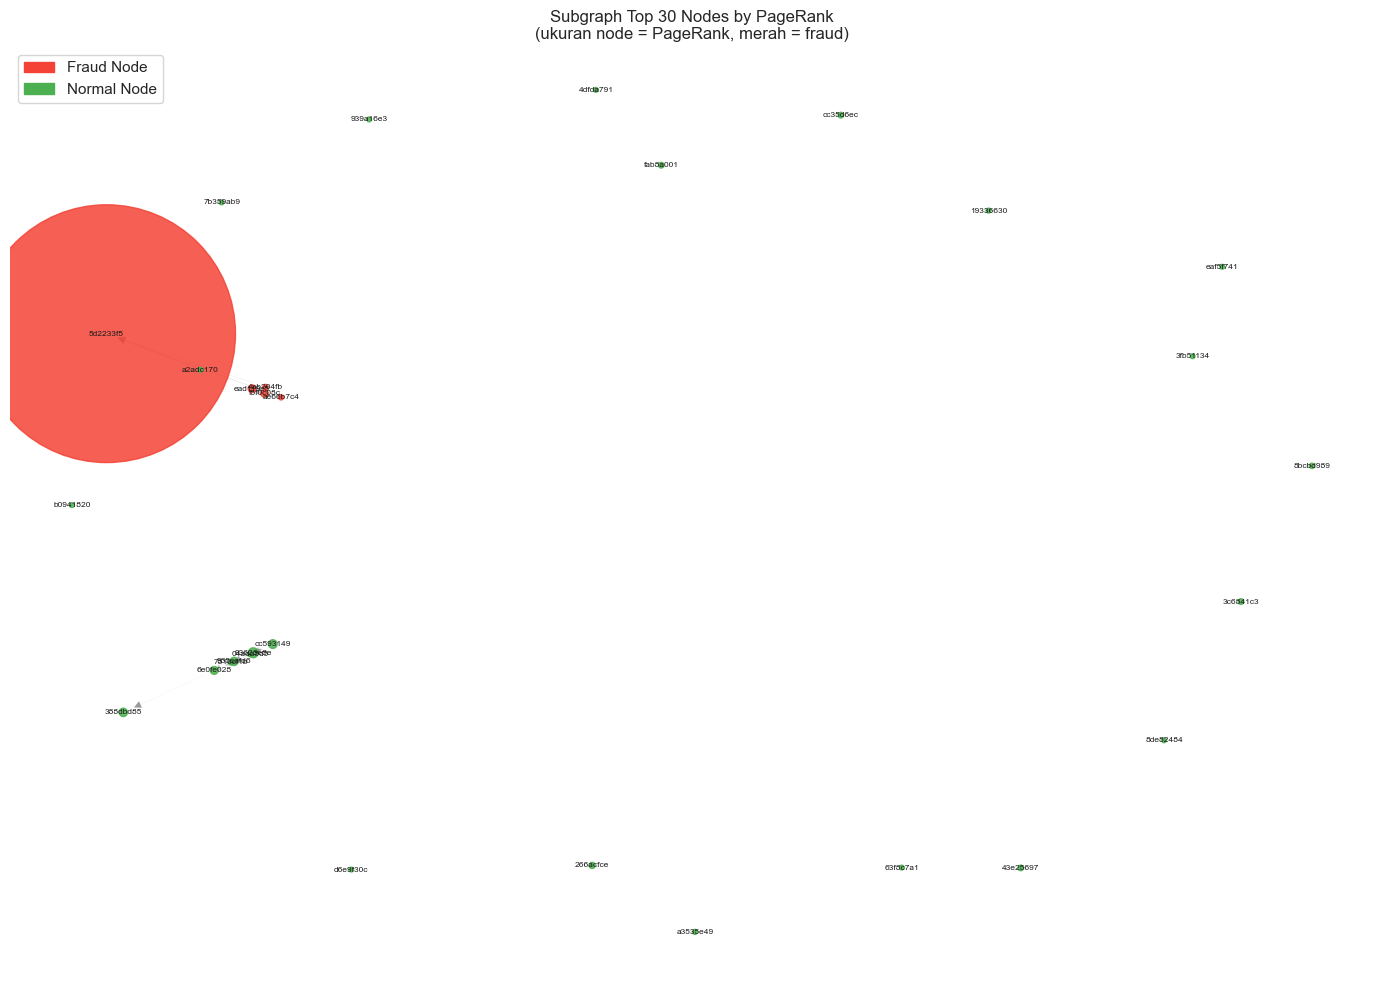

In [7]:
# Ambil top 30 node berdasarkan pagerank untuk visualisasi
top_nodes = centrality_df.head(30)['node'].tolist()
sub_G     = G.subgraph(top_nodes)

fraud_set   = set(centrality_df[centrality_df['is_fraud_node'] == 1]['node'])
node_colors = ['#F44336' if n in fraud_set else '#4CAF50' for n in sub_G.nodes()]
node_sizes  = [pagerank.get(n, 0) * 80000 for n in sub_G.nodes()]
edge_widths = [sub_G[u][v].get('tx_count', 1) * 0.02 for u, v in sub_G.edges()]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(sub_G, seed=42, k=1.5)

nx.draw_networkx_nodes(sub_G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(sub_G, pos, width=edge_widths, alpha=0.4,
                       edge_color='gray', arrows=True, arrowsize=12)
nx.draw_networkx_labels(sub_G, pos,
                        labels={n: n[:8] for n in sub_G.nodes()},
                        font_size=6)

from matplotlib.patches import Patch
legend = [Patch(color='#F44336', label='Fraud Node'),
          Patch(color='#4CAF50', label='Normal Node')]
plt.legend(handles=legend, loc='upper left')
plt.title('Subgraph Top 30 Nodes by PageRank\n(ukuran node = PageRank, merah = fraud)')
plt.axis('off')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_network_subgraph.png', dpi=150)
plt.show()

## 4. Distribusi Degree — Identifikasi Hub Mencurigakan

Total nodes         : 6,843
99th percentile     : 31 transaksi
Hub nodes (> P99)   : 67


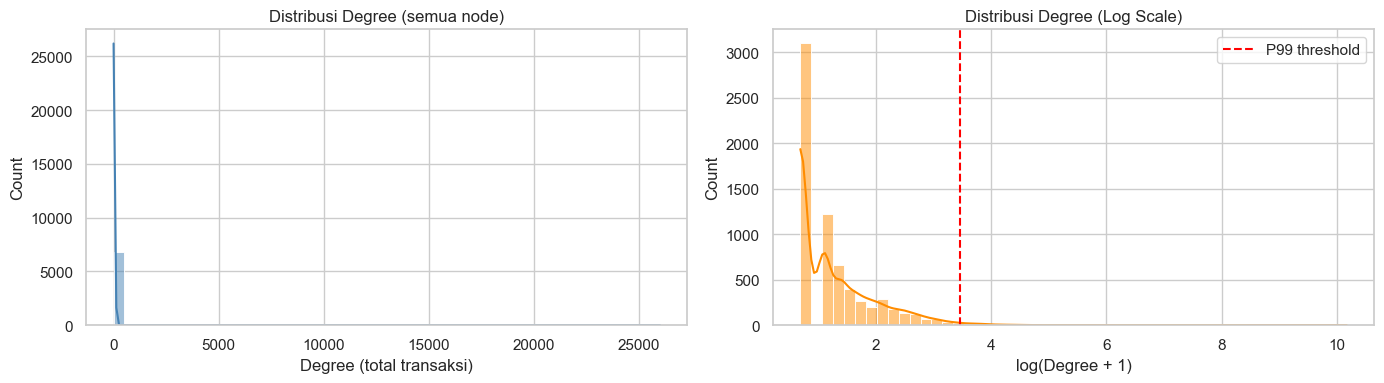

In [8]:
degree_series = pd.Series(dict(G.degree(weight='tx_count')))

q99 = degree_series.quantile(0.99)
hub_nodes = degree_series[degree_series > q99]

print(f'Total nodes         : {len(degree_series):,}')
print(f'99th percentile     : {q99:.0f} transaksi')
print(f'Hub nodes (> P99)   : {len(hub_nodes):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(degree_series, bins=50, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Distribusi Degree (semua node)')
axes[0].set_xlabel('Degree (total transaksi)')

sns.histplot(np.log1p(degree_series), bins=50, ax=axes[1], color='darkorange', kde=True)
axes[1].axvline(np.log1p(q99), color='red', linestyle='--', label=f'P99 threshold')
axes[1].set_title('Distribusi Degree (Log Scale)')
axes[1].set_xlabel('log(Degree + 1)')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_degree_distribution.png', dpi=150)
plt.show()

## 5. Connected Components — Temukan Cluster Fraud

In [9]:
components = list(nx.weakly_connected_components(G))
components_sorted = sorted(components, key=len, reverse=True)

print(f'Jumlah connected components : {len(components):,}')
print(f'Ukuran terbesar             : {len(components_sorted[0]):,} nodes')
print(f'Ukuran terkecil             : {len(components_sorted[-1]):,} nodes')

# Analisis fraud rate per component
comp_stats = []
for i, comp in enumerate(components_sorted[:20]):
    comp_txs  = df[(df['buyer_id'].isin(comp)) | (df['seller_id'].isin(comp))]
    comp_stats.append({
        'component_id' : i,
        'node_count'   : len(comp),
        'tx_count'     : len(comp_txs),
        'fraud_count'  : comp_txs['is_fraud'].sum(),
        'fraud_rate'   : comp_txs['is_fraud'].mean(),
        'total_amount' : comp_txs['transaction_amount'].sum(),
    })

comp_df = pd.DataFrame(comp_stats)
print('\nTop 10 components by size:')
comp_df.head(10)

Jumlah connected components : 112
Ukuran terbesar             : 6,591 nodes
Ukuran terkecil             : 2 nodes

Top 10 components by size:


,component_id,node_count,tx_count,fraud_count,fraud_rate,total_amount
0,0,6591,26589,4630,0.174132,8.134125e+11
1,1,14,32,0,0.000000,3.383910e+07
2,2,5,4,0,0.000000,3.207700e+06
3,3,4,3,0,0.000000,3.497789e+06
4,4,4,3,0,0.000000,1.000877e+07
5,5,3,3,0,0.000000,5.977531e+07
6,6,3,2,0,0.000000,3.106741e+07
7,7,3,3,0,0.000000,4.932900e+08
8,8,3,2,0,0.000000,1.624000e+06
9,9,3,2,0,0.000000,2.302400e+06


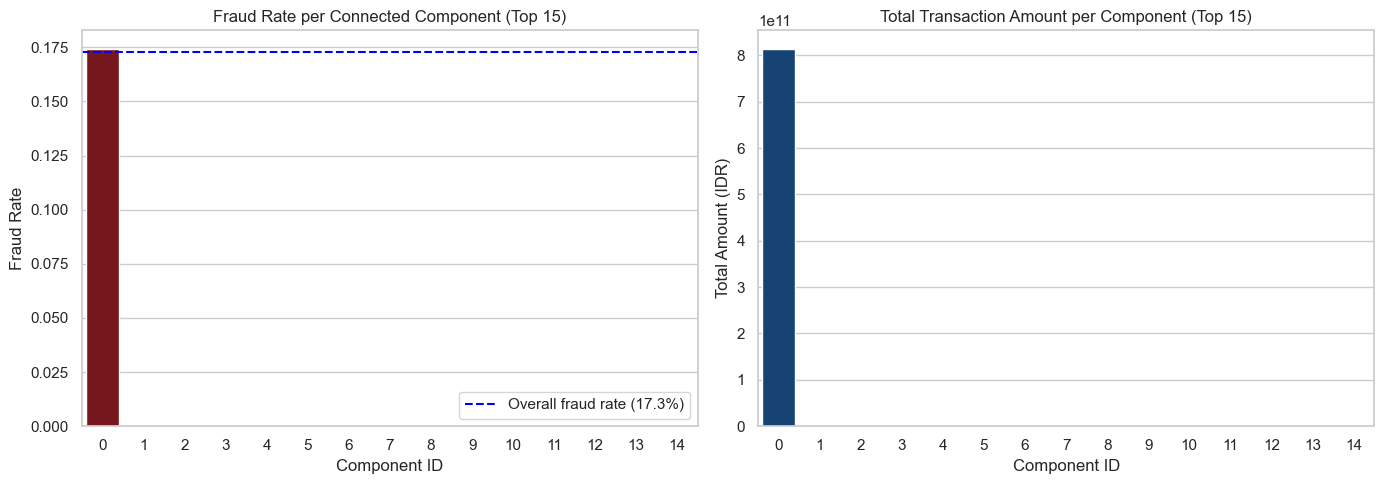

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate per component
sns.barplot(data=comp_df.head(15), x='component_id', y='fraud_rate',
            palette='Reds_r', ax=axes[0])
axes[0].axhline(df['is_fraud'].mean(), color='blue', linestyle='--', label=f'Overall fraud rate ({df["is_fraud"].mean()*100:.1f}%)')
axes[0].set_title('Fraud Rate per Connected Component (Top 15)')
axes[0].set_xlabel('Component ID')
axes[0].set_ylabel('Fraud Rate')
axes[0].legend()

# Total amount per component
sns.barplot(data=comp_df.head(15), x='component_id', y='total_amount',
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Total Transaction Amount per Component (Top 15)')
axes[1].set_xlabel('Component ID')
axes[1].set_ylabel('Total Amount (IDR)')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_components_analysis.png', dpi=150)
plt.show()

## 6. Export Network Data untuk Tableau

In [11]:
# Export node attributes
node_export = centrality_df[[
    'node', 'pagerank', 'in_degree', 'out_degree',
    'betweenness', 'fraud_count', 'avg_fraud_prob', 'is_fraud_node'
]].copy()
node_export.to_csv(PROCESSED_DIR / 'network_nodes.csv', index=False)

# Export edge attributes (top 5000 by tx_count untuk Tableau)
edge_export = edge_df.sort_values('tx_count', ascending=False).head(5000)
edge_export.to_csv(PROCESSED_DIR / 'network_edges.csv', index=False)

# Export component membership
node_to_comp = {}
for i, comp in enumerate(components_sorted):
    for node in comp:
        node_to_comp[node] = i

comp_membership = pd.DataFrame([
    {'node': node, 'component_id': comp_id}
    for node, comp_id in node_to_comp.items()
])
comp_membership.to_csv(PROCESSED_DIR / 'network_components.csv', index=False)

print('Export selesai:')
for fname in ['network_nodes.csv', 'network_edges.csv', 'network_components.csv']:
    p = PROCESSED_DIR / fname
    print(f'  {fname:<30} {p.stat().st_size/1024:.1f} KB')

Export selesai:
  network_nodes.csv              764.3 KB
  network_edges.csv              806.3 KB
  network_components.csv         454.7 KB


## 7. Summary Temuan Network Analysis

In [12]:
high_fraud_comps = comp_df[comp_df['fraud_rate'] > df['is_fraud'].mean()]

print('=== SUMMARY NETWORK ANALYSIS ===')
print(f'Total nodes                    : {G.number_of_nodes():,}')
print(f'Total edges                    : {G.number_of_edges():,}')
print(f'Graph density                  : {nx.density(G):.6f}')
print(f'Connected components           : {len(components):,}')
print(f'Komponen dengan fraud > avg    : {len(high_fraud_comps):,}')
print(f'Hub nodes (>P99 degree)        : {len(hub_nodes):,}')
print(f'\nTop 3 most central fraud nodes:')
print(
    centrality_df[centrality_df['is_fraud_node'] == 1]
    .head(3)[['node', 'pagerank', 'fraud_count', 'avg_fraud_prob']]
    .to_string(index=False)
)

=== SUMMARY NETWORK ANALYSIS ===
Total nodes                    : 6,843
Total edges                    : 6,794
Graph density                  : 0.000145
Connected components           : 112
Komponen dengan fraud > avg    : 1
Hub nodes (>P99 degree)        : 67

Top 3 most central fraud nodes:
                                                            node  pagerank  fraud_count  avg_fraud_prob
5d2233f5a1a6435891142442fac09a77809d0c16496f07b2575c3a451fbd7f60  0.430581         4549        0.285786
ead119c5d1130dc62b309d38a8fa74bc85c9e4302edb6fab61b7e4b703e83a0f  0.000391           13        0.865647
f8f0c08ca6837bf7f41fb600ea803a0131db88f1794b8576a083ececbde0211a  0.000366           12        0.878849
